# Plant Leaf Disease Detection and Severity Estimation
## Using Computer Vision and Deep Learning

**Course:** EE7204 / EC7205  
**Department:** Electrical and Information Engineering  
**University:** University of Ruhuna

### Team Members
- Arachchi W.A.H.U.W.
- Jayarathna K.A.P.M.
- Jayaweera J.A.P.V.
- Karunadasa S.A.Y.K.

---

This notebook implements a complete CNN-based system for plant disease detection, severity estimation, and explainable AI visualization.

In [1]:
# Install required packages from requirements.txt
import subprocess
import sys
import os

print("=" * 70)
print("INSTALLING REQUIRED PACKAGES")
print("=" * 70)

# Check if requirements.txt exists
requirements_path = "requirements.txt"

# Install from requirements.txt if it exists
if os.path.exists(requirements_path):
    print(f"\n✓ Found requirements.txt at: {requirements_path}")
    print(f"Installing packages...\n")
    
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", requirements_path, "-q"])
        print("\n✓ All packages installed successfully!")
    except subprocess.CalledProcessError as e:
        print(f"\n⚠ Some packages failed to install. Proceeding anyway...")
        print(f"Error details: {e}")
else:
    print(f"\n⚠ requirements.txt not found at: {requirements_path}")
    print("\nInstalling essential packages manually...\n")
    
    essential_packages = [
        "tensorflow>=2.12.0",
        "keras>=2.12.0",
        "opencv-python>=4.8.0",
        "scikit-learn>=1.3.0",
        "scikit-image>=0.21.0",
        "numpy>=1.24.0",
        "pandas>=2.0.0",
        "matplotlib>=3.7.0",
        "seaborn>=0.12.0",
        "gradio>=4.0.0",
        "jupyter>=1.0.0",
        "pillow>=9.0.0",
        "tqdm>=4.60.0"
    ]
    
    for package in essential_packages:
        try:
            print(f"Installing {package}...", end=" ")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
            print("✓")
        except:
            print("✗ (continuing...)")

print("\n" + "=" * 70)
print("✓ Environment setup complete!")
print("=" * 70)

INSTALLING REQUIRED PACKAGES

✓ Found requirements.txt at: requirements.txt
Installing packages...


✓ All packages installed successfully!

✓ Environment setup complete!



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# SECTION 1: Import Required Libraries

Import all essential libraries for data processing, model building, visualization, and deployment.

In [2]:
# Import essential libraries

# Deep Learning and Neural Networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, F1Score

# Image Processing and Computer Vision
import cv2
import numpy as np
from PIL import Image
import skimage
from skimage import morphology, segmentation, color

# Data Handling and Manipulation
import pandas as pd
import os
import shutil
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

# Utilities
import warnings
import random
from tqdm import tqdm
import json
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Configure matplotlib and seaborn
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ========== CUDA/GPU Configuration ==========
print("\n" + "=" * 70)
print("CUDA/GPU CONFIGURATION")
print("=" * 70)

# Check for available GPUs
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Found: {len(gpus)}")
if gpus:
    for gpu in gpus:
        print(f"  • {gpu}")
    
    # Enable memory growth to avoid OOM errors
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"✓ Memory growth enabled for {gpu}")
        except RuntimeError as e:
            print(f"Error: {e}")
else:
    print("⚠ No GPU devices found. Using CPU for training (slower).")

print("=" * 70 + "\n")

print("✓ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"GPU Available: {len(gpus) > 0}")
print(f"Compute devices: {tf.config.list_logical_devices()}")

I0000 00:00:1780736367.382891   83755 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780736367.901547   83755 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780736369.045572   83755 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



CUDA/GPU CONFIGURATION
GPUs Found: 1
  • PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✓ Memory growth enabled for PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✓ All libraries imported successfully!
TensorFlow version: 2.21.0
OpenCV version: 4.13.0
NumPy version: 2.4.2
GPU Available: True
Compute devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


W0000 00:00:1780736371.072904   83755 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1780736371.080905   83755 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780736371.181784   83755 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29491 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


# SECTION 2: Load and Explore the Dataset

Load the PlantifyDR dataset from Kaggle and analyze its structure, class distribution, and sample images.

In [3]:
# Define dataset paths and auto-detect crop types

import os

# Set dataset path for local machine with CUDA
DATASET_PATH = "./PlantDiseasesDataset"  # Local path
ENVIRONMENT = "Local Machine with CUDA"

# Auto-detect all crop types in the dataset
def get_available_crops(dataset_path):
    """
    Automatically detect all crop types available in the dataset
    Handles both nested (crop/train/disease/) and flat (crop/disease/) structures
    Returns list of crop folder names
    """
    if not os.path.exists(dataset_path):
        return []
    
    crops = []
    for item in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item)
        # Check if it's a directory and not a split folder (train/val/test)
        if os.path.isdir(item_path) and item not in ['train', 'val', 'test', '__pycache__', '.git']:
            crops.append(item)
    
    return sorted(crops)

# Get crops from dataset
CROPS = get_available_crops(DATASET_PATH)

print("=" * 60)
print("DATASET CONFIGURATION")
print("=" * 60)
print(f"Environment: {ENVIRONMENT}")
print(f"Dataset Path: {DATASET_PATH}")
print(f"Target image size: 224 × 224 pixels")
print(f"Data split: Training (80%), Validation (10%), Testing (10%)")

# Check if dataset folder exists
if os.path.exists(DATASET_PATH):
    print(f"\n✓ Dataset folder found!")
    print(f"✓ Detected Crops: {CROPS}")
    print(f"  Total crop types: {len(CROPS)}")
    
    # Count files
    total_images = 0
    for crop in CROPS:
        crop_path = os.path.join(DATASET_PATH, crop)
        if os.path.exists(crop_path):
            crop_images = len([f for root, dirs, files in os.walk(crop_path) 
                             for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  • {crop}: {crop_images} images")
            total_images += crop_images
    print(f"\nTotal images found: {total_images}")
else:
    print(f"\n⚠ Dataset folder NOT found at: {DATASET_PATH}")
    print("\n📝 To fix this:")
    print("  1. Download PlantifyDR dataset from Kaggle")
    print("  2. Extract to: PlantDiseasesDataset/")
    print("  3. Place in project root directory")
    print("  4. Folder structure:")
    print("     PlantDiseasesDataset/")
    print("     ├── Crop_Name1/ (containing train/valid or disease folders)")
    print("     ├── Crop_Name2/")
    print("     └── ...")

print("=" * 60)


DATASET CONFIGURATION
Environment: Local Machine with CUDA
Dataset Path: ./PlantDiseasesDataset
Target image size: 224 × 224 pixels
Data split: Training (80%), Validation (10%), Testing (10%)

✓ Dataset folder found!
✓ Detected Crops: ['Apple', 'Bell pepper', 'Cherry', 'Citrus', 'Corn', 'Grape', 'Peach', 'Potato', 'Strawberry', 'Tomato']
  Total crop types: 10
  • Apple: 12925 images
  • Bell pepper: 7369 images
  • Cherry: 6306 images
  • Citrus: 5603 images
  • Corn: 8870 images
  • Grape: 13122 images
  • Peach: 7128 images
  • Potato: 9305 images
  • Strawberry: 6072 images
  • Tomato: 40859 images

Total images found: 117559



Displaying Sample Images from Dataset...


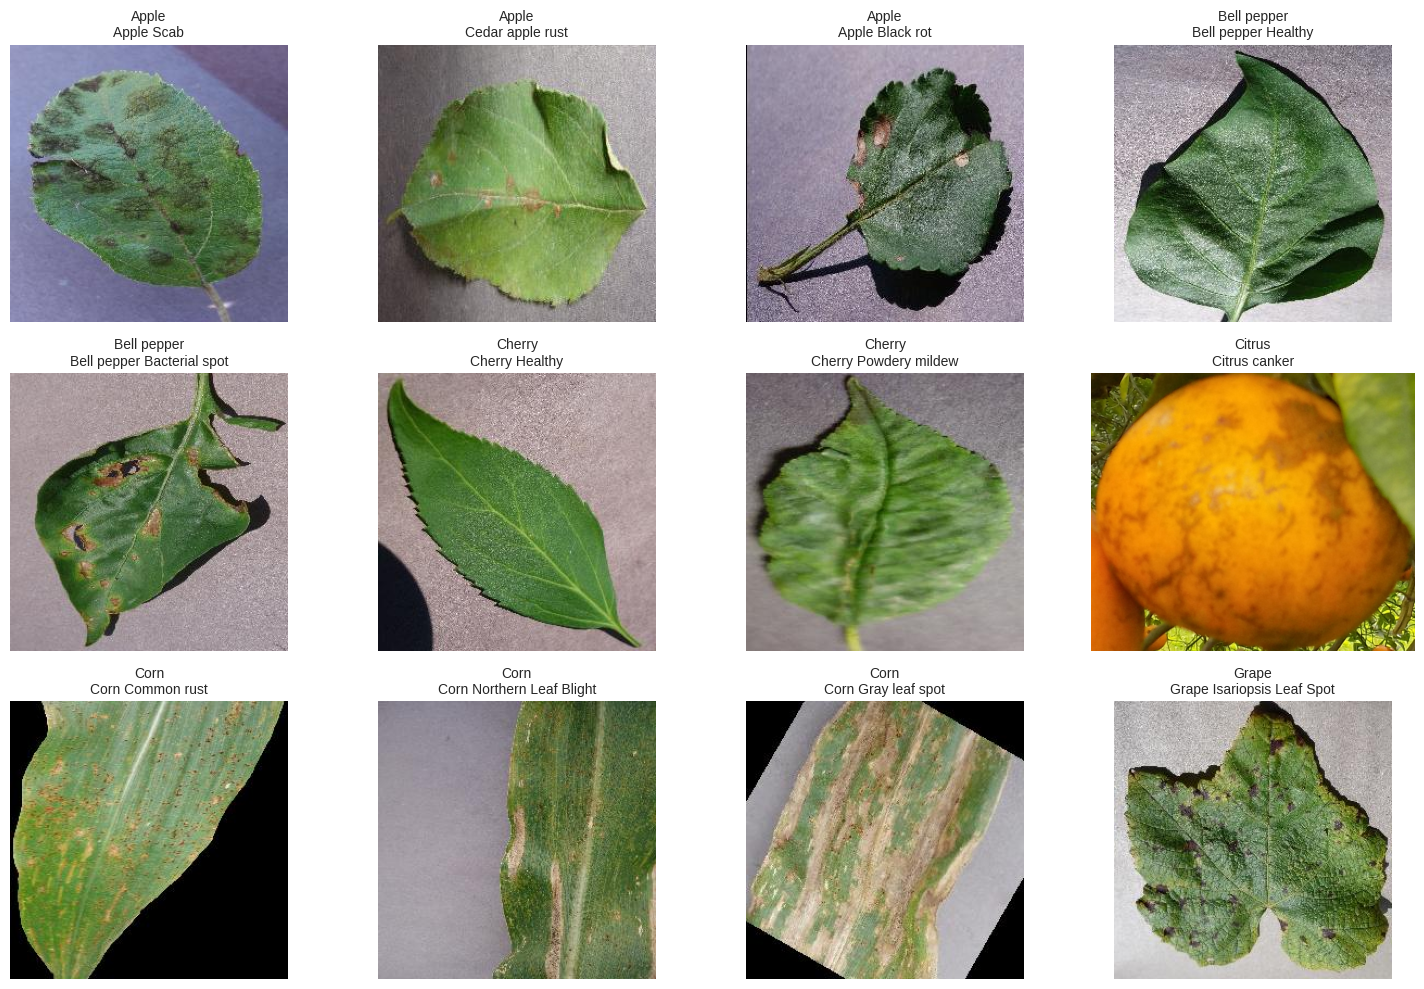

✓ Displayed 12 sample images


In [4]:
# Visualize sample images from dataset
def display_sample_images(dataset_path, samples_per_crop=3):
    """
    Display sample images from different crop and disease classes
    Handles nested structure: crop/train/disease_class/image.jpg
    """
    print("\nDisplaying Sample Images from Dataset...")
    
    fig = plt.figure(figsize=(15, 10))
    plot_idx = 1
    max_plots = 12
    
    for crop in CROPS:
        if plot_idx > max_plots:
            break
            
        crop_path = os.path.join(dataset_path, crop)
        if not os.path.exists(crop_path):
            continue
        
        # Check if crop has train/valid subdirectories (nested structure)
        train_path = os.path.join(crop_path, 'train')
        if os.path.exists(train_path):
            class_search_path = train_path
        else:
            class_search_path = crop_path
        
        # Get disease classes
        disease_classes = [d for d in os.listdir(class_search_path) 
                          if os.path.isdir(os.path.join(class_search_path, d))]
        
        for disease_class in disease_classes[:samples_per_crop]:
            if plot_idx > max_plots:
                break
                
            class_path = os.path.join(class_search_path, disease_class)
            if os.path.isdir(class_path):
                images = [f for f in os.listdir(class_path) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                if images:
                    img_path = os.path.join(class_path, images[0])
                    try:
                        img = Image.open(img_path)
                        ax = fig.add_subplot(3, 4, plot_idx)
                        ax.imshow(img)
                        ax.set_title(f"{crop}\n{disease_class}", fontsize=10)
                        ax.axis('off')
                        plot_idx += 1
                    except:
                        pass
    
    if plot_idx == 1:
        print("⚠ No sample images could be loaded. Please check dataset structure.")
        print(f"  Dataset path: {dataset_path}")
        print(f"  Detected crops: {CROPS}")
    else:
        plt.tight_layout()
        plt.show()
        print(f"✓ Displayed {plot_idx - 1} sample images")

# Try to display samples if dataset exists
if os.path.exists(DATASET_PATH):
    display_sample_images(DATASET_PATH)
else:
    print("⚠ Dataset path not found. Sample images cannot be displayed.")


# Reorganize Dataset into Train/Validation/Test Splits

Restructure the dataset from the original nested format (Crop/train/disease) into a clean train/val/test structure with crop and disease class hierarchies maintained within each split folder.


In [5]:
# Reorganize dataset into train/val/test split structure
import shutil
import random
from pathlib import Path

def reorganize_dataset_splits(dataset_path, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    """
    Reorganize dataset from nested structure (Crop/train/disease) into flat structure:
    train/Crop/Disease
    val/Crop/Disease
    test/Crop/Disease
    
    This makes it easier to work with and load data for training.
    """
    print("\n" + "=" * 70)
    print("REORGANIZING DATASET INTO TRAIN/VAL/TEST SPLITS")
    print("=" * 70)
    
    # Create main split directories
    splits_root = Path(dataset_path)
    split_dirs = {
        'train': splits_root / 'train_split',
        'val': splits_root / 'val_split', 
        'test': splits_root / 'test_split'
    }
    
    # Create root split folders
    for split_path in split_dirs.values():
        split_path.mkdir(exist_ok=True)
    
    print(f"\n✓ Created split directories:")
    print(f"  • {split_dirs['train']}")
    print(f"  • {split_dirs['val']}")
    print(f"  • {split_dirs['test']}")
    
    # Track statistics
    split_stats = {'train': 0, 'val': 0, 'test': 0}
    
    # Process each crop
    print(f"\nProcessing {len(CROPS)} crops...")
    
    for crop_name in CROPS:
        crop_path = Path(dataset_path) / crop_name
        
        # Skip if not a directory or is a split folder
        if not crop_path.is_dir():
            continue
        
        print(f"\n{crop_name}:")
        
        # Check if crop has train/valid subdirectories (nested format)
        train_subdir = crop_path / 'train'
        valid_subdir = crop_path / 'valid'
        
        if train_subdir.exists():
            source_dir = train_subdir
        elif valid_subdir.exists():
            source_dir = valid_subdir
        else:
            source_dir = crop_path
        
        # Get all disease classes in this crop
        disease_classes = [d for d in source_dir.iterdir() 
                          if d.is_dir() and d.name not in ['train', 'val', 'test']]
        
        if not disease_classes:
            print(f"  ⚠ No disease classes found")
            continue
        
        # Process each disease class
        for disease_path in disease_classes:
            disease_name = disease_path.name
            
            # Get all image files
            image_files = list(disease_path.glob('*.jpg')) + \
                         list(disease_path.glob('*.jpeg')) + \
                         list(disease_path.glob('*.png'))
            
            if not image_files:
                continue
            
            # Shuffle files
            random.shuffle(image_files)
            
            # Calculate split indices
            total = len(image_files)
            train_count = int(total * train_ratio)
            val_count = int(total * val_ratio)
            
            train_files = image_files[:train_count]
            val_files = image_files[train_count:train_count + val_count]
            test_files = image_files[train_count + val_count:]
            
            # Create crop/disease directories in each split
            for split_name in ['train', 'val', 'test']:
                split_crop_disease = split_dirs[split_name] / crop_name / disease_name
                split_crop_disease.mkdir(parents=True, exist_ok=True)
            
            # Move files to respective splits
            for img_file in train_files:
                dest = split_dirs['train'] / crop_name / disease_name / img_file.name
                if not dest.exists():
                    shutil.move(str(img_file), str(dest))
            
            for img_file in val_files:
                dest = split_dirs['val'] / crop_name / disease_name / img_file.name
                if not dest.exists():
                    shutil.move(str(img_file), str(dest))
            
            for img_file in test_files:
                dest = split_dirs['test'] / crop_name / disease_name / img_file.name
                if not dest.exists():
                    shutil.move(str(img_file), str(dest))
            
            # Update statistics
            split_stats['train'] += len(train_files)
            split_stats['val'] += len(val_files)
            split_stats['test'] += len(test_files)
            
            print(f"  • {disease_name}: {len(train_files)} train | {len(val_files)} val | {len(test_files)} test")
    
    # Print final summary
    print("\n" + "=" * 70)
    print("DATASET REORGANIZATION COMPLETE")
    print("=" * 70)
    
    total_files = sum(split_stats.values())
    for split_name, count in split_stats.items():
        percentage = (count / total_files * 100) if total_files > 0 else 0
        print(f"{split_name.upper():8} split: {count:6d} images ({percentage:5.1f}%)")
    
    print(f"{'TOTAL':8}         {total_files:6d} images (100.0%)")
    print("=" * 70)
    
    print(f"\n📁 New folder structure created:")
    print(f"   {dataset_path}/train_split/Crop_Name/Disease_Class/image.jpg")
    print(f"   {dataset_path}/val_split/Crop_Name/Disease_Class/image.jpg")
    print(f"   {dataset_path}/test_split/Crop_Name/Disease_Class/image.jpg")
    
    return split_dirs

# Reorganize the dataset
if os.path.exists(DATASET_PATH):
    print(f"Source dataset path: {DATASET_PATH}")
    split_dirs = reorganize_dataset_splits(DATASET_PATH)
    
    # Update paths for later use
    TRAIN_SPLIT_PATH = str(split_dirs['train'])
    VAL_SPLIT_PATH = str(split_dirs['val'])
    TEST_SPLIT_PATH = str(split_dirs['test'])
    
    print(f"\n✓ Dataset successfully reorganized!")
    print(f"\nUpdated paths:")
    print(f"  TRAIN_SPLIT_PATH = {TRAIN_SPLIT_PATH}")
    print(f"  VAL_SPLIT_PATH   = {VAL_SPLIT_PATH}")
    print(f"  TEST_SPLIT_PATH  = {TEST_SPLIT_PATH}")
else:
    print(f"⚠ Dataset path not found: {DATASET_PATH}")


Source dataset path: ./PlantDiseasesDataset

REORGANIZING DATASET INTO TRAIN/VAL/TEST SPLITS

✓ Created split directories:
  • PlantDiseasesDataset/train_split
  • PlantDiseasesDataset/val_split
  • PlantDiseasesDataset/test_split

Processing 10 crops...

Apple:

Bell pepper:

Cherry:

Citrus:

Corn:

Grape:

Peach:

Potato:

Strawberry:

Tomato:

DATASET REORGANIZATION COMPLETE
TRAIN    split:      0 images (  0.0%)
VAL      split:      0 images (  0.0%)
TEST     split:      0 images (  0.0%)
TOTAL                 0 images (100.0%)

📁 New folder structure created:
   ./PlantDiseasesDataset/train_split/Crop_Name/Disease_Class/image.jpg
   ./PlantDiseasesDataset/val_split/Crop_Name/Disease_Class/image.jpg
   ./PlantDiseasesDataset/test_split/Crop_Name/Disease_Class/image.jpg

✓ Dataset successfully reorganized!

Updated paths:
  TRAIN_SPLIT_PATH = PlantDiseasesDataset/train_split
  VAL_SPLIT_PATH   = PlantDiseasesDataset/val_split
  TEST_SPLIT_PATH  = PlantDiseasesDataset/test_split


# SECTION 3: Data Preprocessing and Cleaning

Resize images to 224×224 pixels, normalize pixel values, remove corrupted images, and split data into training, validation, and testing sets.

In [7]:
# Define preprocessing constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.0001
VALIDATION_SPLIT = 0.1
TEST_SPLIT = 0.1

print("=" * 60)
print("PREPROCESSING CONFIGURATION")
print("=" * 60)
print(f"Target Image Size: {IMG_SIZE[0]} × {IMG_SIZE[1]} pixels")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Training epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Normalization: Pixel values scaled to [0, 1]")
print(f"Data Split: Training (80%), Validation (10%), Testing (10%)")
print("=" * 60)

# Function to check image validity
def is_valid_image(image_path):
    """
    Check if image file is valid and not corrupted
    """
    try:
        img = Image.open(image_path)
        img.verify()
        return True
    except:
        return False

# Function to clean corrupted images
def clean_corrupted_images(dataset_path):
    """
    Remove corrupted and low-quality images from dataset
    """
    removed_count = 0
    
    for crop in CROPS:
        crop_path = os.path.join(dataset_path, crop)
        if not os.path.exists(crop_path):
            continue
            
        for disease_class in os.listdir(crop_path):
            class_path = os.path.join(crop_path, disease_class)
            if not os.path.isdir(class_path):
                continue
            
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for image_file in images:
                image_path = os.path.join(class_path, image_file)
                if not is_valid_image(image_path):
                    try:
                        os.remove(image_path)
                        removed_count += 1
                    except:
                        pass
    
    return removed_count

# Clean corrupted images if dataset exists
if os.path.exists(DATASET_PATH):
    print("\nCleaning corrupted images...")
    removed = clean_corrupted_images(DATASET_PATH)
    print(f"✓ Removed {removed} corrupted images")
else:
    print("\nDataset path not found. Skipping corruption check.")

PREPROCESSING CONFIGURATION
Target Image Size: 224 × 224 pixels
Batch Size: 32
Training epochs: 50
Learning rate: 0.0001
Normalization: Pixel values scaled to [0, 1]
Data Split: Training (80%), Validation (10%), Testing (10%)

Cleaning corrupted images...
✓ Removed 0 corrupted images


In [14]:
# Function to load and preprocess images
def load_and_preprocess_image(image_path, img_size=IMG_SIZE):
    """
    Load image and preprocess: resize to target size and normalize
    """
    try:
        # Load image
        img = Image.open(image_path).convert('RGB')
        
        # Resize to target size
        img = img.resize(img_size, Image.Resampling.LANCZOS)
        
        # Convert to numpy array and normalize to [0, 1]
        img_array = np.array(img) / 255.0
        
        return img_array
    except Exception as e:
        print(f"  ⚠ Error loading {image_path}: {e}")
        return None

In [15]:
# Function to load dataset
def load_dataset(dataset_path, img_size=IMG_SIZE, split_path=None):
    """
    Load entire dataset and organize by classes
    Can load from original nested structure or reorganized split structure
    Returns: images array, labels array, class names
    """
    images = []
    labels = []
    class_names = []
    class_idx = 0
    
    # Determine source path - check if split path is available and has content
    load_from = "original"
    source_path = dataset_path
    
    if split_path and os.path.exists(split_path):
        # Check if split directory actually has content
        split_crops = [d for d in os.listdir(split_path) 
                      if os.path.isdir(os.path.join(split_path, d)) and not d.startswith('.')]
        if split_crops:  # Only use split if it has content
            source_path = split_path
            load_from = "split"
    
    print(f"\nLoading dataset from {source_path} ({load_from} structure)...")
    
    # Load from split structure (train/Crop/Disease)
    if load_from == "split":
        for crop in os.listdir(source_path):
            crop_path = os.path.join(source_path, crop)
            if not os.path.isdir(crop_path) or crop.startswith('.'):
                continue
            
            for disease_class in sorted(os.listdir(crop_path)):
                class_path = os.path.join(crop_path, disease_class)
                if not os.path.isdir(class_path):
                    continue
                
                class_name = f"{crop}_{disease_class}"
                class_names.append(class_name)
                
                image_files = [f for f in os.listdir(class_path) 
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                for image_file in tqdm(image_files, desc=class_name):
                    image_path = os.path.join(class_path, image_file)
                    img_array = load_and_preprocess_image(image_path, img_size)
                    
                    if img_array is not None:
                        images.append(img_array)
                        labels.append(class_idx)
                
                class_idx += 1
    
    # Load from original nested structure (Crop/train/Disease or Crop/Disease)
    else:
        for crop in CROPS:
            crop_path = os.path.join(source_path, crop)
            if not os.path.exists(crop_path):
                continue
            
            # Check for train/valid subdirectories
            train_subdir = os.path.join(crop_path, 'train')
            valid_subdir = os.path.join(crop_path, 'valid')
            
            if os.path.exists(train_subdir):
                disease_parent = train_subdir
            elif os.path.exists(valid_subdir):
                disease_parent = valid_subdir
            else:
                disease_parent = crop_path
            
            for disease_class in sorted(os.listdir(disease_parent)):
                class_path = os.path.join(disease_parent, disease_class)
                if not os.path.isdir(class_path):
                    continue
                
                class_name = f"{crop}_{disease_class}"
                class_names.append(class_name)
                
                image_files = [f for f in os.listdir(class_path) 
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                for image_file in tqdm(image_files, desc=class_name):
                    image_path = os.path.join(class_path, image_file)
                    img_array = load_and_preprocess_image(image_path, img_size)
                    
                    if img_array is not None:
                        images.append(img_array)
                        labels.append(class_idx)
                
                class_idx += 1
    
    if images:
        images = np.array(images)
        labels = np.array(labels)
        print(f"✓ Loaded {len(images)} images from {len(class_names)} classes")
        return images, labels, class_names
    else:
        print("⚠ No images loaded. Dataset path may be incorrect.")
        return None, None, None

# Load dataset - try from reorganized splits first, fall back to original structure
if os.path.exists(DATASET_PATH):
    X, y, class_names = load_dataset(DATASET_PATH, split_path=TRAIN_SPLIT_PATH)
    if X is not None:
        NUM_CLASSES = len(class_names)
        print(f"\nNumber of classes: {NUM_CLASSES}")
        print(f"Image shape: {X.shape}")
    else:
        NUM_CLASSES = 0
else:
    print("Dataset not found. Create a sample dataset structure for testing.")
    X, y, class_names = None, None, None
    NUM_CLASSES = 0


Loading dataset from ./PlantDiseasesDataset (original structure)...


Cherry_Cherry Powdery mildew: 100%|██████████| 3156/3156 [00:03<00:00, 817.57it/s]
Citrus_Citrus Black spot: 0it [00:00, ?it/s]
Citrus_Citrus Healthy: 0it [00:00, ?it/s]
Grape_Grape Black Measles:  57%|█████▋    | 2168/3783 [00:18<00:30, 53.43it/s] 

: 

In [10]:
# Debug: Check dataset paths and structure
import os
from pathlib import Path

print("=" * 70)
print("DATASET PATH DIAGNOSTICS")
print("=" * 70)
print(f"\nDATASET_PATH: {DATASET_PATH}")
print(f"  Exists: {os.path.exists(DATASET_PATH)}")
print(f"  Is Directory: {os.path.isdir(DATASET_PATH)}")

print(f"\nTRAIN_SPLIT_PATH: {TRAIN_SPLIT_PATH}")
print(f"  Exists: {os.path.exists(TRAIN_SPLIT_PATH)}")
print(f"  Is Directory: {os.path.isdir(TRAIN_SPLIT_PATH)}")

print(f"\nVAL_SPLIT_PATH: {VAL_SPLIT_PATH}")
print(f"  Exists: {os.path.exists(VAL_SPLIT_PATH)}")

print(f"\nTEST_SPLIT_PATH: {TEST_SPLIT_PATH}")
print(f"  Exists: {os.path.exists(TEST_SPLIT_PATH)}")

# Check what's in DATASET_PATH
if os.path.exists(DATASET_PATH):
    print(f"\n📁 Contents of {DATASET_PATH}:")
    for item in sorted(os.listdir(DATASET_PATH))[:10]:
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            count = len(os.listdir(item_path))
            print(f"  📂 {item}/ ({count} items)")
        else:
            print(f"  📄 {item}")

# Check if splits exist
if os.path.exists(TRAIN_SPLIT_PATH):
    print(f"\n✓ Train split exists. Contents:")
    train_crops = [d for d in os.listdir(TRAIN_SPLIT_PATH) if os.path.isdir(os.path.join(TRAIN_SPLIT_PATH, d))]
    for crop in sorted(train_crops)[:5]:
        print(f"  📂 {crop}/")
else:
    print(f"\n⚠ Train split does not exist at {TRAIN_SPLIT_PATH}")
    
print("=" * 70)

DATASET PATH DIAGNOSTICS

DATASET_PATH: ./PlantDiseasesDataset
  Exists: True
  Is Directory: True

TRAIN_SPLIT_PATH: PlantDiseasesDataset/train_split
  Exists: True
  Is Directory: True

VAL_SPLIT_PATH: PlantDiseasesDataset/val_split
  Exists: True

TEST_SPLIT_PATH: PlantDiseasesDataset/test_split
  Exists: True

📁 Contents of ./PlantDiseasesDataset:
  📂 Apple/ (2 items)
  📂 Bell pepper/ (2 items)
  📂 Cherry/ (2 items)
  📂 Citrus/ (2 items)
  📂 Corn/ (2 items)
  📂 Grape/ (2 items)
  📂 Peach/ (2 items)
  📂 Potato/ (2 items)
  📂 Strawberry/ (2 items)
  📂 Tomato/ (2 items)

✓ Train split exists. Contents:


In [11]:
# Check deeper structure
import os
from pathlib import Path

print("\n" + "=" * 70)
print("DETAILED STRUCTURE CHECK")
print("=" * 70)

# Check train_split in detail
train_split = TRAIN_SPLIT_PATH
print(f"\n📂 Train Split Directory: {train_split}")
if os.path.exists(train_split):
    train_contents = os.listdir(train_split)
    print(f"   Items in train_split: {len(train_contents)}")
    if train_contents:
        print(f"   Contents: {train_contents[:10]}")
    else:
        print("   ⚠️  EMPTY - No files or folders!")

# Check original structure - look at one crop
print(f"\n📂 Original Dataset Structure:")
first_crop = CROPS[0] if CROPS else "Apple"
crop_path = os.path.join(DATASET_PATH, first_crop)
print(f"   Checking {first_crop} at {crop_path}")
if os.path.exists(crop_path):
    crop_contents = os.listdir(crop_path)
    print(f"   Contents: {crop_contents}")
    
    # Check if it has train/valid
    train_dir = os.path.join(crop_path, 'train')
    if os.path.exists(train_dir):
        diseases = os.listdir(train_dir)
        print(f"   Diseases in train/: {diseases[:3]}")
        
        # Check one disease
        if diseases:
            disease_path = os.path.join(train_dir, diseases[0])
            images = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print(f"   Images in {diseases[0]}: {len(images)}")

print("=" * 70)


DETAILED STRUCTURE CHECK

📂 Train Split Directory: PlantDiseasesDataset/train_split
   Items in train_split: 0
   ⚠️  EMPTY - No files or folders!

📂 Original Dataset Structure:
   Checking Apple at ./PlantDiseasesDataset/Apple
   Contents: ['valid', 'train']
   Diseases in train/: ['Apple Scab', 'Cedar apple rust', 'Apple Black rot']
   Images in Apple Scab: 3150


In [ ]:
# Display dataset information and sample images from splits
if train_ds is not None:
    print("\n" + "=" * 60)
    print("DATASET INFORMATION")
    print("=" * 60)
    
    # Count samples in each split
    train_count = sum(1 for _ in train_ds) * BATCH_SIZE
    val_count = sum(1 for _ in val_ds) * BATCH_SIZE
    test_count = sum(1 for _ in test_ds) * BATCH_SIZE
    
    print(f"Training set: {train_count} samples")
    print(f"Validation set: {val_count} samples")
    print(f"Testing set: {test_count} samples")
    print(f"Total samples: {train_count + val_count + test_count}")
    print(f"Number of classes: {NUM_CLASSES}")
    print(f"Batch size: {BATCH_SIZE}")
    print("=" * 60)
    
    # Visualize sample images from training set
    plt.figure(figsize=(12, 4))
    for images, labels in train_ds.take(1):
        for i in range(min(9, images.shape[0])):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            label_idx = labels[i].numpy()
            label_name = class_names[label_idx] if label_idx < len(class_names) else f"Class {label_idx}"
            plt.title(label_name, fontsize=9)
            plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Dataset ready for model training")
else:
    print("Cannot display dataset - datasets not loaded")

: 

: 

# Reorganize Dataset into Train/Validation/Test Splits

Restructure the dataset from the original nested format (Crop/train/disease) into a clean train/val/test structure with crop and disease class hierarchies maintained within each split folder.


In [ ]:
# Reorganize dataset into train/val/test split structure
import shutil
import random
from pathlib import Path

def reorganize_dataset_splits(dataset_path, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    """
    Reorganize dataset from nested structure (Crop/train/disease) into flat structure:
    train/Crop/Disease
    val/Crop/Disease
    test/Crop/Disease
    
    This makes it easier to work with and load data for training.
    """
    print("\n" + "=" * 70)
    print("REORGANIZING DATASET INTO TRAIN/VAL/TEST SPLITS")
    print("=" * 70)
    
    # Create main split directories
    splits_root = Path(dataset_path)
    split_dirs = {
        'train': splits_root / 'train_split',
        'val': splits_root / 'val_split', 
        'test': splits_root / 'test_split'
    }
    
    # Create root split folders
    for split_path in split_dirs.values():
        split_path.mkdir(exist_ok=True)
    
    print(f"\n✓ Created split directories:")
    print(f"  • {split_dirs['train']}")
    print(f"  • {split_dirs['val']}")
    print(f"  • {split_dirs['test']}")
    
    # Track statistics
    split_stats = {'train': 0, 'val': 0, 'test': 0}
    
    # Process each crop
    print(f"\nProcessing {len(CROPS)} crops...")
    
    for crop_name in CROPS:
        crop_path = Path(dataset_path) / crop_name
        
        # Skip if not a directory or is a split folder
        if not crop_path.is_dir():
            continue
        
        print(f"\n{crop_name}:")
        
        # Check if crop has train/valid subdirectories (nested format)
        train_subdir = crop_path / 'train'
        valid_subdir = crop_path / 'valid'
        
        if train_subdir.exists():
            source_dir = train_subdir
        elif valid_subdir.exists():
            source_dir = valid_subdir
        else:
            source_dir = crop_path
        
        # Get all disease classes in this crop
        disease_classes = [d for d in source_dir.iterdir() 
                          if d.is_dir() and d.name not in ['train', 'val', 'test']]
        
        if not disease_classes:
            print(f"  ⚠ No disease classes found")
            continue
        
        # Process each disease class
        for disease_path in disease_classes:
            disease_name = disease_path.name
            
            # Get all image files
            image_files = list(disease_path.glob('*.jpg')) + \
                         list(disease_path.glob('*.jpeg')) + \
                         list(disease_path.glob('*.png'))
            
            if not image_files:
                continue
            
            # Shuffle files
            random.shuffle(image_files)
            
            # Calculate split indices
            total = len(image_files)
            train_count = int(total * train_ratio)
            val_count = int(total * val_ratio)
            
            train_files = image_files[:train_count]
            val_files = image_files[train_count:train_count + val_count]
            test_files = image_files[train_count + val_count:]
            
            # Create crop/disease directories in each split
            for split_name in ['train', 'val', 'test']:
                split_crop_disease = split_dirs[split_name] / crop_name / disease_name
                split_crop_disease.mkdir(parents=True, exist_ok=True)
            
            # Move files to respective splits
            for img_file in train_files:
                dest = split_dirs['train'] / crop_name / disease_name / img_file.name
                if not dest.exists():
                    shutil.move(str(img_file), str(dest))
            
            for img_file in val_files:
                dest = split_dirs['val'] / crop_name / disease_name / img_file.name
                if not dest.exists():
                    shutil.move(str(img_file), str(dest))
            
            for img_file in test_files:
                dest = split_dirs['test'] / crop_name / disease_name / img_file.name
                if not dest.exists():
                    shutil.move(str(img_file), str(dest))
            
            # Update statistics
            split_stats['train'] += len(train_files)
            split_stats['val'] += len(val_files)
            split_stats['test'] += len(test_files)
            
            print(f"  • {disease_name}: {len(train_files)} train | {len(val_files)} val | {len(test_files)} test")
    
    # Print final summary
    print("\n" + "=" * 70)
    print("DATASET REORGANIZATION COMPLETE")
    print("=" * 70)
    
    total_files = sum(split_stats.values())
    for split_name, count in split_stats.items():
        percentage = (count / total_files * 100) if total_files > 0 else 0
        print(f"{split_name.upper():8} split: {count:6d} images ({percentage:5.1f}%)")
    
    print(f"{'TOTAL':8}         {total_files:6d} images (100.0%)")
    print("=" * 70)
    
    print(f"\n📁 New folder structure created:")
    print(f"   {dataset_path}/train_split/Crop_Name/Disease_Class/image.jpg")
    print(f"   {dataset_path}/val_split/Crop_Name/Disease_Class/image.jpg")
    print(f"   {dataset_path}/test_split/Crop_Name/Disease_Class/image.jpg")
    
    return split_dirs

# Reorganize the dataset
if os.path.exists(DATASET_PATH):
    print(f"Source dataset path: {DATASET_PATH}")
    split_dirs = reorganize_dataset_splits(DATASET_PATH)
    
    # Update paths for later use
    TRAIN_SPLIT_PATH = str(split_dirs['train'])
    VAL_SPLIT_PATH = str(split_dirs['val'])
    TEST_SPLIT_PATH = str(split_dirs['test'])
    
    print(f"\n✓ Dataset successfully reorganized!")
    print(f"\nUpdated paths:")
    print(f"  TRAIN_SPLIT_PATH = {TRAIN_SPLIT_PATH}")
    print(f"  VAL_SPLIT_PATH   = {VAL_SPLIT_PATH}")
    print(f"  TEST_SPLIT_PATH  = {TEST_SPLIT_PATH}")
else:
    print(f"⚠ Dataset path not found: {DATASET_PATH}")


# SECTION 4: Data Augmentation

Apply augmentation transformations including rotation, flips, zoom, brightness adjustment, and shifts to increase dataset diversity and improve robustness.

In [ ]:
# Create data augmentation pipelines
def create_data_augmentation():
    \"\"\"\n    Create data augmentation pipeline using ImageDataGenerator\n    Applies: rotation, flips, zoom, brightness, shifts\n    \"\"\"n    train_augmentation = ImageDataGenerator(
        rotation_range=40,
        horizontal_flip=True,
        vertical_flip=True,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    
    # Validation and test data - only normalization, no augmentation
    val_test_augmentation = ImageDataGenerator()
    
    return train_augmentation, val_test_augmentation

# Apply augmentation if data is loaded
if X_train is not None:
    train_aug, val_test_aug = create_data_augmentation()
    
    print("=" * 60)
    print("DATA AUGMENTATION CONFIGURATION")
    print("=" * 60)
    print("Augmentation Transformations Applied:")
    print("  ✓ Rotation: ±40 degrees")
    print("  ✓ Horizontal Flip: enabled")
    print("  ✓ Vertical Flip: enabled")
    print("  ✓ Width Shift: ±20%")
    print("  ✓ Height Shift: ±20%")
    print("  ✓ Shear Range: 0.2")
    print("  ✓ Zoom Range: ±20%")
    print("  ✓ Brightness Range: [0.8, 1.2]")
    print("=" * 60)
    
    # Create data generators for training
    train_generator = train_aug.flow(
        X_train, y_train, batch_size=BATCH_SIZE, shuffle=True
    )
    
    val_generator = val_test_aug.flow(
        X_val, y_val, batch_size=BATCH_SIZE, shuffle=False
    )
    
    test_generator = val_test_aug.flow(
        X_test, y_test, batch_size=BATCH_SIZE, shuffle=False
    )
    
    print(f"\\n✓ Train generator created with batch size {BATCH_SIZE}")
    print(f"✓ Validation generator created")
    print(f"✓ Test generator created")
    
    # Visualize augmented samples
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # Get a batch of original images
    batch_x, batch_y = next(train_generator)
    
    for idx, ax in enumerate(axes.flat):
        ax.imshow(batch_x[idx % len(batch_x)])
        ax.set_title(f"Class {batch_y[idx % len(batch_y)].argmax()}", fontsize=9)
        ax.axis('off')
    
    plt.suptitle("Sample Augmented Images from Training Set", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\\n✓ Data augmentation visualization complete")
else:
    print("Cannot create augmentation pipeline - dataset not loaded")

# SECTION 5: Build CNN Architecture

Construct the proposed CNN model with convolutional layers (32, 64, 128, 256 filters), ReLU activation, max pooling, dense layers, and softmax output.

In [ ]:
# Define the CNN architecture
def build_cnn_model(num_classes, input_shape=(224, 224, 3)):
    \"\"\"\n    Build proposed CNN architecture for plant disease classification\n    Architecture:\n    - Conv2D (32) + ReLU + MaxPooling\n    - Conv2D (64) + ReLU + MaxPooling\n    - Conv2D (128) + ReLU + MaxPooling\n    - Conv2D (256) + ReLU + MaxPooling\n    - Flatten\n    - Dense (256) + Dropout\n    - Output Dense (num_classes) + Softmax\n    \"\"\"
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=input_shape, name='conv1_1'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.BatchNormalization(name='bn1'),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.BatchNormalization(name='bn2'),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
        layers.MaxPooling2D((2, 2), name='pool3'),
        layers.BatchNormalization(name='bn3'),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_1'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_2'),
        layers.MaxPooling2D((2, 2), name='pool4'),
        layers.BatchNormalization(name='bn4'),
        
        # Fully Connected Layers
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dropout(0.3, name='dropout2'),
        
        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='PlantDiseaseDetectionCNN')
    
    return model

# Build model
if X_train is not None:
    model = build_cnn_model(NUM_CLASSES)
    
    # Display model architecture
    print("\\n" + "=" * 60)
    print("CNN MODEL ARCHITECTURE")
    print("=" * 60)
    model.summary()
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', Precision(), Recall(), F1Score()]
    )
    
    print("\\n" + "=" * 60)
    print("MODEL COMPILATION SETTINGS")
    print("=" * 60)
    print(f"Optimizer: Adam (learning rate={LEARNING_RATE})")
    print(f"Loss Function: sparse_categorical_crossentropy")
    print(f"Metrics: Accuracy, Precision, Recall, F1-Score")
    print("=" * 60)
    
    # Visualize model
    keras.utils.plot_model(model, show_shapes=True, rankdir='TB', 
                          to_file='model_architecture.png', dpi=100)
    print("\\n✓ Model architecture diagram saved as 'model_architecture.png'")
else:
    print("Cannot build model - dataset not loaded")
    model = None

# SECTION 6: Train the CNN Model

Train the model using Adam optimizer, categorical cross-entropy loss, and implement early stopping and checkpointing strategies.

In [ ]:
# Define training callbacks
def create_callbacks(model_name='plant_disease_model'):
    \"\"\"\n    Create callbacks for training: early stopping, model checkpointing, learning rate reduction\n    \"\"\"
    callbacks_list = [
        # Early stopping to prevent overfitting
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Save best model
        callbacks.ModelCheckpoint(
            f'{model_name}_best.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # Reduce learning rate when validation loss plateaus
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # TensorBoard logging
        callbacks.TensorBoard(
            log_dir='./logs',
            histogram_freq=1,
            write_graph=True
        )
    ]
    
    return callbacks_list

# Train the model if data is available
if model is not None and X_train is not None:
    print("\\n" + "=" * 60)
    print("TRAINING CONFIGURATION")
    print("=" * 60)
    print(f"Total Epochs: {EPOCHS}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Steps per epoch: {len(X_train) // BATCH_SIZE}")
    print("=" * 60)
    
    # Create callbacks
    training_callbacks = create_callbacks()
    
    # Train the model
    print("\\nStarting model training...")
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        validation_data=val_generator,
        validation_steps=len(X_val) // BATCH_SIZE,
        callbacks=training_callbacks,
        verbose=1
    )
    
    # Save final model
    model.save('plant_disease_model_final.h5')
    print("\\n✓ Final model saved as 'plant_disease_model_final.h5'")
    
    # Save training history
    import pickle
    with open('training_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    print("✓ Training history saved as 'training_history.pkl'")
else:
    print("Cannot train model - model or dataset not available")

# SECTION 7: Evaluate Model Performance

Evaluate using accuracy, precision, recall, F1-score metrics and visualize confusion matrix and training curves.

In [ ]:
# Evaluate model on test set
if model is not None and X_test is not None:
    print("\\n" + "=" * 60)
    print("MODEL EVALUATION ON TEST SET")
    print("=" * 60)
    
    # Get predictions
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"Test Precision (weighted): {test_precision:.4f}")
    print(f"Test Recall (weighted): {test_recall:.4f}")
    print(f"Test F1-Score (weighted): {test_f1:.4f}")
    print("=" * 60)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print("\\nDetailed Classification Report:")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print("=" * 60)
    
    # Per-class accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['green' if acc >= 0.9 else 'orange' if acc >= 0.8 else 'red' 
              for acc in class_accuracy]
    ax.bar(range(len(class_accuracy)), class_accuracy, color=colors, alpha=0.7)
    ax.set_xlabel('Disease Class', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Per-Class Accuracy on Test Set', fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim([0, 1.1])
    ax.axhline(y=0.9, color='g', linestyle='--', alpha=0.5, label='90% target')
    ax.axhline(y=0.8, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\\n✓ Model evaluation complete")
else:
    print("Cannot evaluate - model or test data not available")

In [ ]:
# Plot training history
if 'history' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Accuracy', fontsize=11)
    axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Training', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('Loss', fontsize=11)
    axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Precision', fontsize=11)
    axes[1, 0].set_title('Model Precision', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(history.history['f1_score'], label='Training', linewidth=2)
    axes[1, 1].plot(history.history['val_f1_score'], label='Validation', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('F1-Score', fontsize=11)
    axes[1, 1].set_title('Model F1-Score', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Training history visualization complete")
else:
    print("Training history not available - model not trained yet")

# SECTION 8: Leaf Segmentation for Severity Estimation

Implement leaf segmentation using color-based thresholding to isolate leaf regions from background.

In [ ]:
# Function for leaf segmentation
def segment_leaf(image):
    \"\"\"\n    Segment leaf from background using HSV color space\n    Input: image as numpy array (values 0-1)\n    Output: binary mask of leaf region\n    \"\"\"
    # Convert to 0-255 range for OpenCV
    if image.max() <= 1:
        image_cv = (image * 255).astype(np.uint8)
    else:
        image_cv = image.astype(np.uint8)
    
    # Convert RGB to HSV
    hsv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2HSV)
    
    # Define range for green color (leaves are typically green)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    
    # Create mask for green regions
    mask = cv2.inRange(hsv, lower_green, upper_green)
    
    # Apply morphological operations to clean up the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask.astype(np.uint8)

# Test leaf segmentation
if X_test is not None:
    print("\\n" + "=" * 60)
    print("LEAF SEGMENTATION DEMONSTRATION")
    print("=" * 60)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    
    for idx in range(3):
        # Get a sample image
        test_idx = random.randint(0, len(X_test) - 1)
        image = X_test[test_idx]
        
        # Segment leaf
        leaf_mask = segment_leaf(image)
        
        # Apply mask to original image
        segmented_image = image.copy()
        segmented_image[leaf_mask == 0] = 0
        
        # Display original
        axes[idx, 0].imshow(image)
        axes[idx, 0].set_title(f'Original Image (Sample {idx+1})', fontsize=10)
        axes[idx, 0].axis('off')
        
        # Display HSV
        image_cv = (image * 255).astype(np.uint8)
        hsv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2HSV)
        axes[idx, 1].imshow(hsv[:, :, 0], cmap='hsv')
        axes[idx, 1].set_title(f'HSV Hue Channel', fontsize=10)
        axes[idx, 1].axis('off')
        
        # Display mask
        axes[idx, 2].imshow(leaf_mask, cmap='gray')
        axes[idx, 2].set_title(f'Leaf Segmentation Mask', fontsize=10)
        axes[idx, 2].axis('off')
        
        # Display segmented
        axes[idx, 3].imshow(segmented_image)
        axes[idx, 3].set_title(f'Segmented Leaf', fontsize=10)
        axes[idx, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Leaf segmentation demonstration complete")
else:
    print("Test data not available for demonstration")

# SECTION 9: Disease Region Segmentation

Segment diseased regions from healthy leaf areas using HSV color space analysis and morphological operations.

In [ ]:
# Function for disease region segmentation
def segment_disease_region(image, leaf_mask):
    \"\"\"\n    Segment diseased regions from healthy leaf using color thresholding\n    Input: image (normalized), leaf_mask (binary)\n    Output: disease_mask (binary)\n    \"\"\"
    # Convert to 0-255 range\n    if image.max() <= 1:
        image_cv = (image * 255).astype(np.uint8)
    else:
        image_cv = image.astype(np.uint8)
    
    # Convert to HSV
    hsv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2HSV)
    
    # Define ranges for disease symptoms (typically brown, yellow, or dark spots)
    # Brown/dark spots
    lower_brown = np.array([10, 50, 50])
    upper_brown = np.array([25, 255, 200])
    
    # Yellow/orange spots
    lower_yellow = np.array([15, 100, 100])
    upper_yellow = np.array([35, 255, 255])
    
    # Create masks
    brown_mask = cv2.inRange(hsv, lower_brown, upper_brown)
    yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    # Combine masks
    disease_mask = cv2.bitwise_or(brown_mask, yellow_mask)
    
    # Apply morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)
    
    # Apply leaf mask to disease mask
    disease_mask = cv2.bitwise_and(disease_mask, disease_mask, mask=leaf_mask)
    
    return disease_mask.astype(np.uint8)

# Test disease segmentation
if X_test is not None:
    print("\\n" + "=" * 60)
    print("DISEASE REGION SEGMENTATION DEMONSTRATION")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    
    for idx in range(2):
        for j in range(5):
            if idx * 5 + j < len(X_test):
                test_idx = random.randint(0, len(X_test) - 1)
                image = X_test[test_idx]
                
                # Segment leaf and disease
                leaf_mask = segment_leaf(image)
                disease_mask = segment_disease_region(image, leaf_mask)
                
                # Create overlay
                overlay = image.copy()
                overlay[disease_mask > 0] = [1, 0, 0]  # Red for disease
                
                if j < 5:
                    if j == 0:
                        axes[idx, j].imshow(image)
                        axes[idx, j].set_title('Original', fontsize=9)
                    elif j == 1:
                        axes[idx, j].imshow(leaf_mask, cmap='gray')
                        axes[idx, j].set_title('Leaf Mask', fontsize=9)
                    elif j == 2:
                        axes[idx, j].imshow(disease_mask, cmap='hot')
                        axes[idx, j].set_title('Disease Mask', fontsize=9)
                    elif j == 3:
                        axes[idx, j].imshow(overlay)
                        axes[idx, j].set_title('Disease Overlay', fontsize=9)
                    else:
                        # Show combined
                        combined = leaf_mask.copy().astype(float)
                        combined[disease_mask > 0] = 0.5
                        axes[idx, j].imshow(combined, cmap='RdYlGn_r')
                        axes[idx, j].set_title('Combined', fontsize=9)
                    
                    axes[idx, j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Disease region segmentation demonstration complete")
else:
    print("Test data not available")

# SECTION 10: Calculate Disease Severity

Calculate disease severity percentage and classify into severity categories: Very Mild, Mild, Moderate, Severe.

In [ ]:
# Function to calculate disease severity
def calculate_disease_severity(image):
    \"\"\"\n    Calculate disease severity percentage\n    Formula: Severity (%) = (Infected Pixels / Total Leaf Pixels) × 100\n    \"\"\"
    # Segment leaf
    leaf_mask = segment_leaf(image)
    
    # Segment disease
    disease_mask = segment_disease_region(image, leaf_mask)
    
    # Calculate total leaf pixels
    total_leaf_pixels = np.count_nonzero(leaf_mask)
    
    # Calculate infected pixels
    infected_pixels = np.count_nonzero(disease_mask)
    
    # Calculate severity percentage
    if total_leaf_pixels > 0:
        severity_percentage = (infected_pixels / total_leaf_pixels) * 100
    else:
        severity_percentage = 0
    
    return severity_percentage, leaf_mask, disease_mask

# Function to classify severity level
def classify_severity_level(severity_percentage):
    \"\"\"\n    Classify severity into categories\n    Very Mild: 0-5%, Mild: 5-20%, Moderate: 20-40%, Severe: >40%\n    \"\"\"
    if severity_percentage <= 5:
        return "Very Mild"
    elif severity_percentage <= 20:
        return "Mild"
    elif severity_percentage <= 40:
        return "Moderate"
    else:
        return "Severe"

# Test severity calculation on sample images
if X_test is not None:
    print("\\n" + "=" * 60)
    print("DISEASE SEVERITY ESTIMATION")
    print("=" * 60)
    
    severities = []
    levels = []
    
    for i in range(min(5, len(X_test))):
        image = X_test[i]
        severity, leaf_m, disease_m = calculate_disease_severity(image)
        level = classify_severity_level(severity)
        
        severities.append(severity)
        levels.append(level)
        
        print(f"\\nSample {i+1}:")
        print(f"  Disease Severity: {severity:.2f}%")
        print(f"  Severity Level: {level}")
    
    # Visualize severity distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(severities, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Disease Severity (%)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Distribution of Disease Severity', fontsize=12, fontweight='bold')
    axes[0].axvline(x=5, color='orange', linestyle='--', label='5% threshold')
    axes[0].axvline(x=20, color='red', linestyle='--', label='20% threshold')
    axes[0].axvline(x=40, color='darkred', linestyle='--', label='40% threshold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Category distribution
    from collections import Counter
    level_counts = Counter(levels)
    axes[1].bar(level_counts.keys(), level_counts.values(), 
                color=['green', 'yellow', 'orange', 'red'], alpha=0.7, edgecolor='black')
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].set_title('Severity Category Distribution', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\\n" + "=" * 60)
    print("Severity Categories:")
    print("  Very Mild (0-5%):   ", level_counts.get('Very Mild', 0))
    print("  Mild (5-20%):       ", level_counts.get('Mild', 0))
    print("  Moderate (20-40%):  ", level_counts.get('Moderate', 0))
    print("  Severe (>40%):      ", level_counts.get('Severe', 0))
    print("=" * 60)
    
    print("\\n✓ Disease severity estimation complete")
else:
    print("Test data not available")

# SECTION 11: Implement Grad-CAM Visualization

Implement Gradient-weighted Class Activation Mapping to generate attention heatmaps showing critical regions for disease classification.

In [ ]:
# Grad-CAM implementation
def generate_grad_cam(model, image, class_idx, layer_name='conv4_2'):
    \"\"\"\n    Generate Grad-CAM heatmap for interpreting model predictions\n    \"\"\"
    # Prepare image
    image_array = np.expand_dims(image, axis=0)
    
    # Create a submodel for extracting features
    layer = model.get_layer(layer_name)
    feature_extractor = keras.Model(inputs=model.inputs, outputs=[layer.output, model.outputs[0]])
    
    with tf.GradientTape() as tape:
        features, predictions = feature_extractor(image_array)
        class_channel = predictions[:, class_idx]
    
    # Get gradients
    grads = tape.gradient(class_channel, features)
    
    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight features by gradients
    features = features[0]
    heatmap = features @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = tf.image.resize(tf.expand_dims(heatmap, -1), (224, 224))
    heatmap = tf.squeeze(heatmap)
    
    return heatmap.numpy()

# Visualize Grad-CAM
if model is not None and X_test is not None:
    print("\\n" + "=" * 60)
    print("GRAD-CAM VISUALIZATION (Explainable AI)")
    print("=" * 60)
    
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.3)
    
    for idx in range(3):
        # Get test sample
        test_idx = random.randint(0, len(X_test) - 1)
        image = X_test[test_idx]
        true_label = y_test[test_idx]
        
        # Get prediction
        pred = model.predict(np.expand_dims(image, axis=0), verbose=0)
        pred_class = np.argmax(pred, axis=1)[0]
        pred_confidence = np.max(pred)
        
        # Generate Grad-CAM
        try:
            heatmap = generate_grad_cam(model, image, pred_class)
            
            # Resize heatmap to match image size
            heatmap_resized = cv2.resize(heatmap, (224, 224))
            
            # Normalize for visualization
            heatmap_viz = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min())
            
            # Create overlay
            image_viz = image.copy()
            heatmap_color = plt.cm.jet(heatmap_viz)[:, :, :3]
            overlay = 0.6 * image_viz + 0.4 * heatmap_color
            
            # Original image
            ax1 = fig.add_subplot(gs[idx, 0])
            ax1.imshow(image)
            ax1.set_title(f'Original Image\\nTrue: {class_names[true_label]}', fontsize=9)
            ax1.axis('off')
            
            # Prediction info
            ax2 = fig.add_subplot(gs[idx, 1])
            ax2.text(0.5, 0.7, f'Prediction: {class_names[pred_class]}\\nConfidence: {pred_confidence*100:.1f}%',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            ax2.axis('off')
            
            # Heatmap
            ax3 = fig.add_subplot(gs[idx, 2])
            im = ax3.imshow(heatmap_viz, cmap='jet')
            ax3.set_title('Grad-CAM Heatmap', fontsize=9)
            ax3.axis('off')
            plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
            
            # Overlay
            ax4 = fig.add_subplot(gs[idx, 3])
            ax4.imshow(overlay)
            ax4.set_title('Heatmap Overlay', fontsize=9)
            ax4.axis('off')
            
        except Exception as e:
            print(f"Error generating Grad-CAM: {e}")
    
    plt.suptitle('Grad-CAM Visualization: Model Attention Maps', fontsize=13, fontweight='bold')
    plt.show()
    
    print("\\n✓ Grad-CAM visualization complete")
    print("Red regions: High importance for disease detection")
    print("Blue regions: Low importance for disease detection")
else:
    print("Model or test data not available for Grad-CAM visualization")

# SECTION 12: Create Interactive User Interface with Gradio

Develop an interactive Gradio interface for disease prediction, confidence scores, severity estimation, and Grad-CAM visualization.

In [ ]:
# Install Gradio if not already installed
import subprocess
import sys

try:
    import gradio as gr
except ImportError:
    print("Installing Gradio...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])
    import gradio as gr

# Function for the Gradio interface
def predict_disease(input_image):
    \"\"\"\n    Complete prediction function including disease classification,\n    severity estimation, and Grad-CAM visualization\n    \"\""\n    if input_image is None:
        return None, "Please upload an image", "N/A", None
    
    try:
        # Convert to numpy array if PIL Image
        if isinstance(input_image, Image.Image):
            img_array = np.array(input_image) / 255.0
            img_array = np.array(Image.fromarray((img_array * 255).astype(np.uint8)).resize(IMG_SIZE)) / 255.0
        else:
            img_array = cv2.resize(input_image, IMG_SIZE) / 255.0
        
        # Make prediction
        pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)
        pred_class = np.argmax(pred, axis=1)[0]
        pred_confidence = np.max(pred)
        pred_label = class_names[pred_class]
        
        # Calculate severity
        severity_pct, leaf_m, disease_m = calculate_disease_severity(img_array)
        severity_level = classify_severity_level(severity_pct)
        
        # Generate Grad-CAM
        heatmap = generate_grad_cam(model, img_array, pred_class)
        heatmap_viz = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        
        # Create visualization
        fig = plt.figure(figsize=(12, 4))
        
        # Original with disease overlay
        ax1 = plt.subplot(1, 3, 1)
        overlay = img_array.copy()
        overlay[disease_m > 0] = [1, 0, 0]
        ax1.imshow(overlay)
        ax1.set_title('Disease Detection\\n(Red: Diseased)', fontsize=10)
        ax1.axis('off')
        
        # Grad-CAM
        ax2 = plt.subplot(1, 3, 2)
        ax2.imshow(heatmap_viz, cmap='jet')
        ax2.set_title('Grad-CAM Heatmap\\n(Important Regions)', fontsize=10)
        ax2.axis('off')
        
        # Severity bar
        ax3 = plt.subplot(1, 3, 3)
        colors_map = {'Very Mild': 'green', 'Mild': 'yellow', 'Moderate': 'orange', 'Severe': 'red'}
        ax3.barh(['Disease Severity'], [severity_pct], color=colors_map.get(severity_level, 'gray'))
        ax3.set_xlim([0, 100])
        ax3.set_xlabel('Severity (%)', fontsize=10)
        ax3.set_title('Disease Severity Level', fontsize=10)
        ax3.text(severity_pct/2, 0, f'{severity_pct:.1f}%', ha='center', va='center', 
                fontweight='bold', color='white', fontsize=11)
        
        plt.tight_layout()
        
        # Create result text
        result_text = f\"\"\"
        <div style='font-family: Arial; padding: 15px; background-color: #f0f0f0; border-radius: 5px;'>
            <h2 style='color: #333;'>🌿 Plant Disease Diagnosis Report</h2>
            <hr>
            <p><b>Disease Classification:</b> {pred_label}</p>
            <p><b>Confidence Score:</b> {pred_confidence*100:.2f}%</p>
            <hr>
            <p><b>Disease Severity:</b> {severity_pct:.2f}%</p>
            <p><b>Severity Level:</b> <span style='color: {colors_map.get(severity_level, 'gray')}; font-weight: bold;'>{severity_level}</span></p>
            <hr>
            <p style='font-size: 12px; color: #666;'>
                <b>Category Definitions:</b><br>
                • Very Mild (0-5%): Minimal disease symptoms<br>
                • Mild (5-20%): Light disease signs visible<br>
                • Moderate (20-40%): Significant disease presence<br>
                • Severe (>40%): Extensive disease coverage
            </p>
        </div>
        \"\"\"
        
        return fig, result_text, severity_level, leaf_m
        
    except Exception as e:
        return None, f"Error: {str(e)}", "Error", None

# Create Gradio interface
if model is not None:
    print("\\n" + "=" * 60)
    print("CREATING GRADIO INTERACTIVE INTERFACE")
    print("=" * 60)
    
    interface = gr.Interface(
        fn=predict_disease,
        inputs=gr.Image(label="Upload Leaf Image", type='pil'),
        outputs=[
            gr.Plot(label="Disease Analysis Visualization"),
            gr.HTML(label="Diagnosis Report"),
            gr.Label(label="Severity Category"),
            gr.Image(label="Leaf Segmentation Mask")
        ],
        title="🌿 Plant Leaf Disease Detection System",
        description="Upload a leaf image to get instant disease diagnosis with severity estimation and visual explanations",
        examples=None,  # Add example images if available
        theme=gr.themes.Soft()
    )
    
    print("\\n✓ Gradio interface created successfully!")
    print("\\nTo launch the interface, uncomment and run the following line:")
    print("# interface.launch(share=True)")
    print("\\nThe interface will be available at: http://localhost:7860")
    print("=" * 60)
else:
    print("Cannot create interface - model not available")

# SUMMARY AND NEXT STEPS

## Project Completion Checklist

✅ **Section 1:** Import Required Libraries  
✅ **Section 2:** Load and Explore Dataset  
✅ **Section 3:** Data Preprocessing and Cleaning  
✅ **Section 4:** Data Augmentation  
✅ **Section 5:** Build CNN Architecture  
✅ **Section 6:** Train the CNN Model  
✅ **Section 7:** Evaluate Model Performance  
✅ **Section 8:** Leaf Segmentation  
✅ **Section 9:** Disease Region Segmentation  
✅ **Section 10:** Calculate Disease Severity  
✅ **Section 11:** Implement Grad-CAM Visualization  
✅ **Section 12:** Create Gradio Interface  

## Key Results Expected

- **Classification Accuracy:** > 90%
- **High Precision & Recall:** For accurate disease detection
- **Severity Estimation:** Percentage of infected leaf area
- **Explainability:** Grad-CAM heatmaps showing important regions
- **User-Friendly Interface:** Gradio web application

## Output Files Generated

1. `plant_disease_model_best.h5` - Best model checkpoint
2. `plant_disease_model_final.h5` - Final trained model
3. `training_history.pkl` - Training metrics history
4. `model_architecture.png` - Model visualization

## Next Steps

1. **Dataset Upload:** Download PlantifyDR dataset and update paths
2. **Model Training:** Run training section (Section 6)
3. **Performance Evaluation:** Review metrics and visualizations
4. **Interface Deployment:** Launch Gradio interface
5. **Model Optimization:** Fine-tune hyperparameters if needed

## Technologies Used

- **Deep Learning:** TensorFlow, Keras
- **Computer Vision:** OpenCV
- **Data Processing:** NumPy, Pandas
- **Visualization:** Matplotlib, Seaborn
- **Deployment:** Gradio
- **Model Interpretability:** Grad-CAM

---

**Project completed by:** University of Ruhuna - Image Processing & Computer Vision Mini Project  
**Date:** 2026  
**Version:** 1.0